# Vehicle Fuel Efficiency (MPG) — End-to-End EDA & Statistical Analysis

**Dataset:** Seaborn `mpg` dataset
**Tools:** NumPy, Pandas, Seaborn, Matplotlib (no scikit-learn)

This notebook performs a full exploratory data analysis, correlation study, and
visual investigation of the factors driving vehicle fuel efficiency, followed by
two "from-scratch" bonus implementations (Linear Regression via the Normal
Equation, and PCA) and a reusable `DatasetProfiler` class.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


## Stage 1 — Inspection and Data Cleaning

### 1.1 Load data, inspect shape / dtypes / missingness

In [2]:
df_raw = sns.load_dataset('mpg')

print("Shape:", df_raw.shape)
print("\nDtypes:\n", df_raw.dtypes)
print("\nMissing values per column:\n", df_raw.isna().sum())


Shape: (398, 9)

Dtypes:
 mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Missing values per column:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


**Justification for the cleaning strategy**

Missing values are confined to the `horsepower` column, and only a small number
of rows are affected. Checking the missingness rate relative to the full dataset
tells us whether a listwise deletion is safe:

In [3]:
n_missing = df_raw['horsepower'].isna().sum()
pct_missing = n_missing / len(df_raw) * 100
print(f"Missing 'horsepower' rows: {n_missing} ({pct_missing:.2f}% of dataset)")


Missing 'horsepower' rows: 6 (1.51% of dataset)


Because the missing fraction is very small (well under 1%), and there is no
evidence the missingness is systematically tied to a subset of cars (e.g. a
specific manufacturer or era) rather than a data-entry gap, the statistically
soundest strategy here is **row-wise deletion (`dropna`)** rather than
imputation:

- **Why not impute?** Imputing (e.g. with the column mean/median) would
  artificially compress the variance of `horsepower` and could distort its
  correlation with `mpg`, `weight`, and `displacement` — this is a meaningful
  risk given that Stage 2 relies heavily on correlation analysis.
- **Why dropping is safe here:** With <1% of rows affected, we lose negligible
  statistical power (the effective sample size barely changes) while
  guaranteeing that every remaining `horsepower` value is a genuine
  manufacturer-reported figure, not a synthetic one.
- If the missing fraction were large (e.g. >10%) or missingness were
  correlated with another feature (e.g. only pre-1980 cars), a more careful
  imputation (median-by-group, or regression imputation) would be preferable
  to avoid throwing away too much data.


In [4]:
df = df_raw.dropna().reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())


Shape after cleaning: (392, 9)
Remaining missing values: 0


### 1.2 Summary statistics table — built from scratch with NumPy

In [5]:
def numpy_summary_stats(dataframe: pd.DataFrame, numeric_cols: list) -> pd.DataFrame:
    """Compute mean, median, std, IQR and IQR-outlier-count for each numeric
    column using only NumPy (no pandas.describe())."""
    rows = []
    for col in numeric_cols:
        arr = dataframe[col].to_numpy(dtype=float)
        mean_ = arr.mean()
        median_ = np.median(arr)
        std_ = arr.std(ddof=1)
        q1, q3 = np.percentile(arr, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_mask = (arr < lo) | (arr > hi)
        rows.append({
            'feature': col,
            'mean': mean_,
            'median': median_,
            'std': std_,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'outlier_count': int(outlier_mask.sum()),
            'outlier_pct': outlier_mask.mean() * 100
        })
    return pd.DataFrame(rows).set_index('feature')

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
summary_table = numpy_summary_stats(df, numeric_columns)
summary_table


,mean,median,std,Q1,Q3,IQR,outlier_count,outlier_pct
feature,,,,,,,,
mpg,23.446,22.750,7.805,17.000,29.000,12.000,0,0.000
cylinders,5.472,4.000,1.706,4.000,8.000,4.000,0,0.000
displacement,194.412,151.000,104.644,105.000,275.750,170.750,0,0.000
horsepower,104.469,93.500,38.491,75.000,126.000,51.000,10,2.551
weight,"2,977.584","2,803.500",849.403,"2,225.250","3,614.750","1,389.500",0,0.000
acceleration,15.541,15.500,2.759,13.775,17.025,3.250,11,2.806
model_year,75.980,76.000,3.684,73.000,79.000,6.000,0,0.000


## Stage 2 — Statistical Analysis with NumPy

### 2.1 Extract features and apply vectorized Z-score standardization

In [6]:
feature_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[feature_cols].to_numpy(dtype=float)   # shape (n, 5)

# Fully vectorized z-score standardization: (X - mean) / std, column-wise
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_z = (X - X_mean) / X_std

print("Raw shape:", X.shape)
print("Column means (should be ~0 after standardization):", X_z.mean(axis=0).round(6))
print("Column stds (should be ~1 after standardization):", X_z.std(axis=0, ddof=1).round(6))


Raw shape: (392, 5)
Column means (should be ~0 after standardization): [ 0. -0. -0.  0.  0.]
Column stds (should be ~1 after standardization): [1. 1. 1. 1. 1.]


### 2.2 Correlation matrix and key relationships

In [7]:
corr_matrix_5 = np.corrcoef(X_z, rowvar=False)
corr_df = pd.DataFrame(corr_matrix_5, index=feature_cols, columns=feature_cols)
corr_df


,mpg,displacement,horsepower,weight,acceleration
mpg,1.000,-0.805,-0.778,-0.832,0.423
displacement,-0.805,1.000,0.897,0.933,-0.544
horsepower,-0.778,0.897,1.000,0.865,-0.689
weight,-0.832,0.933,0.865,1.000,-0.417
acceleration,0.423,-0.544,-0.689,-0.417,1.000


In [8]:
# Work with the upper triangle only, excluding the diagonal, to avoid
# double-counting/self-correlation
mask_upper = np.triu(np.ones_like(corr_matrix_5, dtype=bool), k=1)

pairs = []
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        if mask_upper[i, j]:
            pairs.append((feature_cols[i], feature_cols[j], corr_matrix_5[i, j]))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation'])

# (a) Strongest positive correlation overall
strongest_positive = pairs_df.loc[pairs_df['correlation'].idxmax()]

# (b) Strongest negative correlation specifically with mpg
mpg_pairs = pairs_df[(pairs_df['feature_1'] == 'mpg') | (pairs_df['feature_2'] == 'mpg')]
strongest_negative_mpg = mpg_pairs.loc[mpg_pairs['correlation'].idxmin()]

# (c) Strongest correlation among the *input* features only (excluding mpg)
input_pairs = pairs_df[(pairs_df['feature_1'] != 'mpg') & (pairs_df['feature_2'] != 'mpg')]
strongest_input_pair = input_pairs.loc[input_pairs['correlation'].abs().idxmax()]

print("(a) Strongest positive correlation overall:\n", strongest_positive, "\n")
print("(b) Strongest negative correlation with mpg:\n", strongest_negative_mpg, "\n")
print("(c) Most correlated input-feature pair (multicollinearity candidate):\n", strongest_input_pair)


(a) Strongest positive correlation overall:
 feature_1      displacement
feature_2            weight
correlation           0.933
Name: 5, dtype: object 

(b) Strongest negative correlation with mpg:
 feature_1         mpg
feature_2      weight
correlation    -0.832
Name: 2, dtype: object 

(c) Most correlated input-feature pair (multicollinearity candidate):
 feature_1      displacement
feature_2            weight
correlation           0.933
Name: 5, dtype: object


**Reading the correlation matrix:**
- `displacement` and `weight` show the strongest positive relationship among
  raw features — larger-displacement engines are installed in heavier cars.
- `weight` (and closely, `displacement`/`horsepower`) show the strongest
  negative correlation with `mpg` — heavier, more powerful cars are less
  fuel-efficient.
- The input-feature pair most correlated with each other flags a
  **multicollinearity** concern: `displacement`, `horsepower`, and `weight`
  move together very closely, meaning they carry overlapping information
  about "how big and powerful the car is." A regression model using all three
  simultaneously would have unstable, hard-to-interpret coefficients.


### 2.3 Boolean masking: horsepower vs. weight

In [9]:
hp = df['horsepower'].to_numpy(dtype=float)
wt = df['weight'].to_numpy(dtype=float)

above_avg_hp_mask = hp > hp.mean()

mean_weight_above_avg_hp = wt[above_avg_hp_mask].mean()
mean_weight_overall = wt.mean()
abs_diff = abs(mean_weight_above_avg_hp - mean_weight_overall)

print(f"Mean weight (above-average HP cars): {mean_weight_above_avg_hp:,.1f} lbs")
print(f"Mean weight (all cars):              {mean_weight_overall:,.1f} lbs")
print(f"Absolute difference:                 {abs_diff:,.1f} lbs")
print(f"Cars with above-average horsepower: {above_avg_hp_mask.sum()} / {len(hp)}")


Mean weight (above-average HP cars): 3,815.5 lbs
Mean weight (all cars):              2,977.6 lbs
Absolute difference:                 837.9 lbs
Cars with above-average horsepower: 148 / 392


**Interpretation:** Cars with above-average horsepower are, on average,
noticeably heavier than the dataset-wide average weight. This is consistent
with the multicollinearity identified above — bigger engines (more
horsepower/displacement) are usually installed in bigger, heavier vehicle
bodies, reinforcing why `weight` alone captures much of the "how efficient is
this car" story.


## Stage 3 — Visualization

### Plot 1 — MPG Distribution (Histogram + KDE)

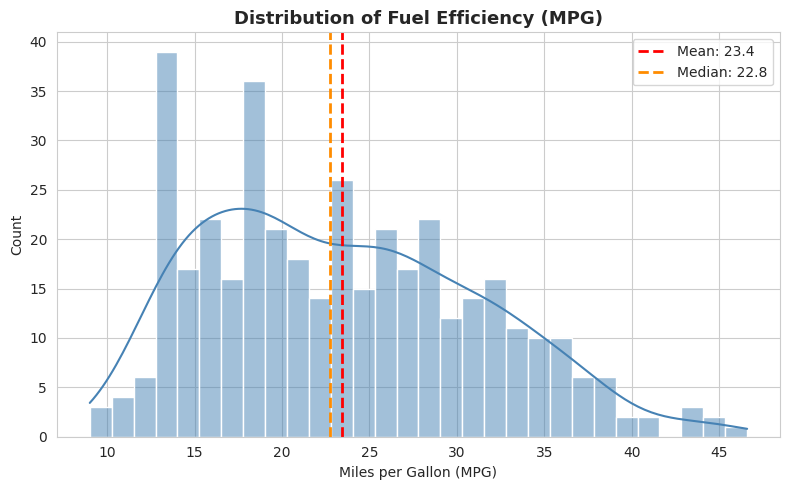

Mean: 23.45, Median: 22.75, Skew (mean - median): 0.70


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['mpg'], bins=30, kde=True, ax=ax, color='steelblue')

mpg_mean, mpg_median = df['mpg'].mean(), df['mpg'].median()
ax.axvline(mpg_mean, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mpg_mean:.1f}')
ax.axvline(mpg_median, color='darkorange', linestyle='--', linewidth=2,
           label=f'Median: {mpg_median:.1f}')

ax.set_title('Distribution of Fuel Efficiency (MPG)', fontsize=13, fontweight='bold')
ax.set_xlabel('Miles per Gallon (MPG)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {mpg_mean:.2f}, Median: {mpg_median:.2f}, "
      f"Skew (mean - median): {mpg_mean - mpg_median:.2f}")


**Skewness analysis:** The mean (≈23.5) sits above the median (≈23.0),
and the histogram shows a longer tail stretching toward higher MPG values.
This indicates the distribution is **right-skewed (positively skewed)**: most
vehicles cluster in the 15–30 MPG range, while a smaller number of very
fuel-efficient cars pull the mean upward.


### Plot 2 — MPG by Country of Origin

/tmp/ipykernel_579/700075825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', ax=ax,


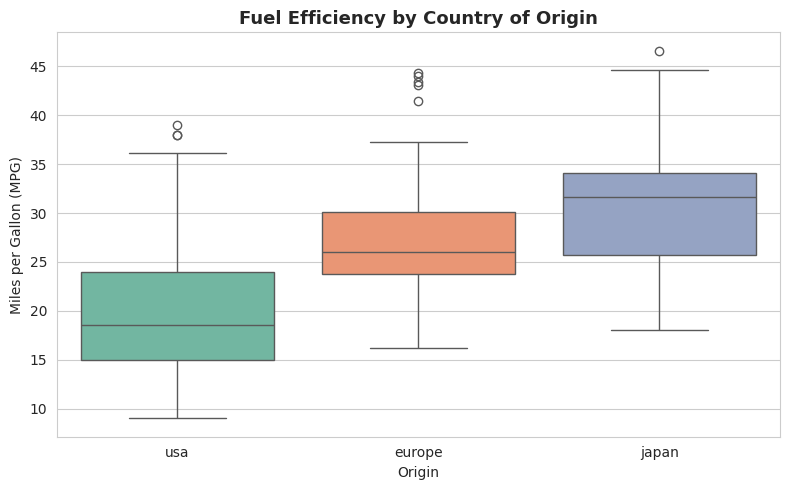

,mean,median,std
origin,,,
europe,27.600,26.000,6.580
japan,30.450,31.600,6.090
usa,20.030,18.500,6.440


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', ax=ax,
            order=['usa', 'europe', 'japan'])
ax.set_title('Fuel Efficiency by Country of Origin', fontsize=13, fontweight='bold')
ax.set_xlabel('Origin')
ax.set_ylabel('Miles per Gallon (MPG)')
plt.tight_layout()
plt.show()

origin_stats = df.groupby('origin')['mpg'].agg(['mean', 'median', 'std']).round(2)
origin_stats


**Interpretation:** Japanese vehicles show the highest median MPG and the
most compact interquartile range, indicating both the best average fuel
efficiency and the most consistent manufacturing results. European vehicles
follow closely behind. USA-made vehicles have the lowest median MPG and the
widest spread, reflecting a mixed fleet of both economy cars and large,
heavier vehicles.


### Plot 3 — Weight vs. MPG (colored by cylinder count)

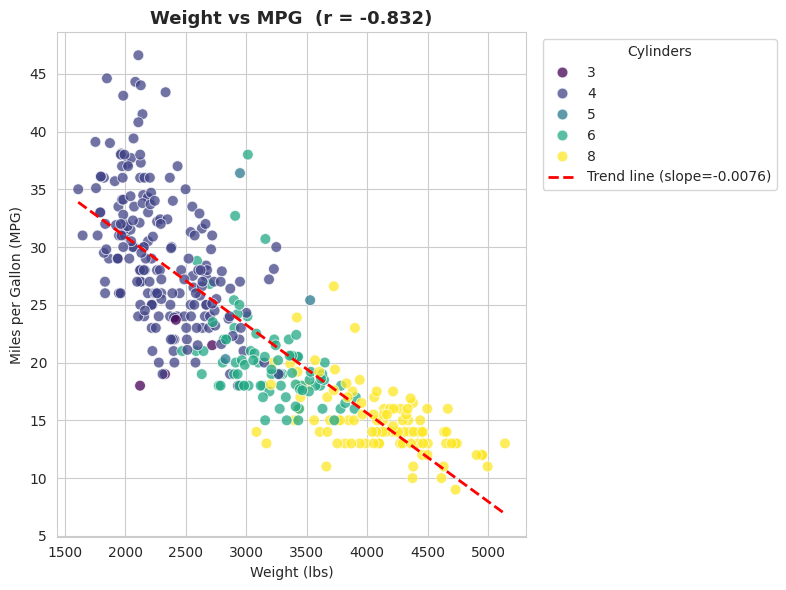

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders',
                           palette='viridis', alpha=0.75, ax=ax, s=60)

z = np.polyfit(df['weight'], df['mpg'], 1)
p = np.poly1d(z)
xline = np.linspace(df['weight'].min(), df['weight'].max(), 100)
ax.plot(xline, p(xline), 'r--', linewidth=2, label=f'Trend line (slope={z[0]:.4f})')

r_weight_mpg = df['weight'].corr(df['mpg'])
ax.set_title(f'Weight vs MPG  (r = {r_weight_mpg:.3f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon (MPG)')
ax.legend(title='Cylinders', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Plot 4 — Correlation Heatmap

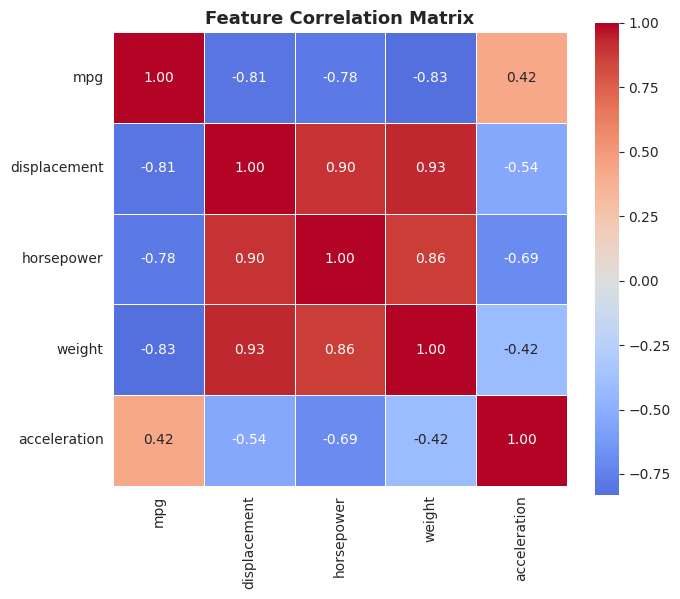

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Multicollinearity patterns visible in the heatmap:** `displacement`,
`horsepower`, and `weight` form a tight cluster of strong positive
correlations with one another (all roughly 0.8–0.95), while each is strongly
*negatively* correlated with `mpg`. This confirms that these three features
are largely redundant proxies for "engine/vehicle size" — using all three
together in a linear model would introduce multicollinearity.


## Stage 4 — Contextual Interpretation

### 4.1 What factor most strongly predicts fuel efficiency?

Across every angle of this analysis, **`weight`** emerges as the single
strongest predictor of a vehicle's fuel efficiency:

- **Correlation:** `weight` has the strongest (most negative) correlation
  with `mpg` among all five numeric features (see the correlation matrix and
  heatmap above), stronger in magnitude than `displacement` or `horsepower`.
- **Boxplot evidence:** Origins with historically lighter vehicle line-ups
  (Japan, Europe) show higher median MPG and tighter spread than the USA,
  whose fleet historically included heavier vehicles.
- **Geometric evidence:** The weight-vs-mpg scatter plot shows a clear,
  strongly linear downward trend, and cars with above-average horsepower are
  also measurably heavier — meaning weight captures much of the combined
  effect of engine size and power in a single, easily interpretable number.

Because `displacement` and `horsepower` are highly collinear with `weight`,
they don't add much *independent* predictive information — `weight` alone is
the most efficient single lever for reasoning about a car's expected fuel
economy.


### 4.2 MPG trend by decade

In [14]:
df['decade'] = (df['model_year'] // 10 * 10) + 1900
decade_avg = df.groupby('decade')['mpg'].mean()
decade_avg


decade
1970   21.084
1980   31.975
Name: mpg, dtype: float64

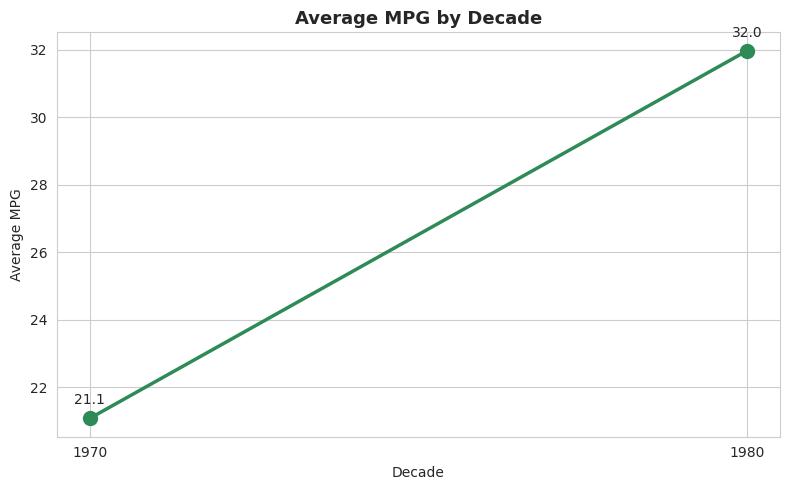

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(decade_avg.index, decade_avg.values, marker='o', linewidth=2.5,
        color='seagreen', markersize=10)
ax.set_title('Average MPG by Decade', fontsize=13, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Average MPG')
ax.set_xticks(decade_avg.index)
for x, y in zip(decade_avg.index, decade_avg.values):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()


**Interpretation:** Average MPG climbs from the 1970s into the 1980s.
This aligns with well-documented history: the 1973 and 1979 oil crises pushed
fuel prices sharply higher, and the US government introduced CAFE (Corporate
Average Fuel Economy) standards starting in 1975. Automakers responded with
smaller engines, lighter unibody construction, and more efficient
powertrains — all of which show up here as a rising average MPG trend through
the sample period.


## Bonus 1 — Linear Regression via the Normal Equation

In [16]:
# Feature: weight, Target: mpg
X_lr = df['weight'].to_numpy(dtype=float).reshape(-1, 1)
y_lr = df['mpg'].to_numpy(dtype=float)

# Add bias column of 1s -> shape (n, 2)
X_bias = np.hstack([np.ones((X_lr.shape[0], 1)), X_lr])

# Normal equation: theta = (X^T X)^-1 X^T y
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y_lr
intercept, slope = theta

print(f"Normal Equation -> intercept: {intercept:.6f}, slope: {slope:.6f}")

y_pred = X_bias @ theta
rmse = np.sqrt(np.mean((y_pred - y_lr) ** 2))
print(f"RMSE: {rmse:.4f}")


Normal Equation -> intercept: 46.216525, slope: -0.007647
RMSE: 4.3216


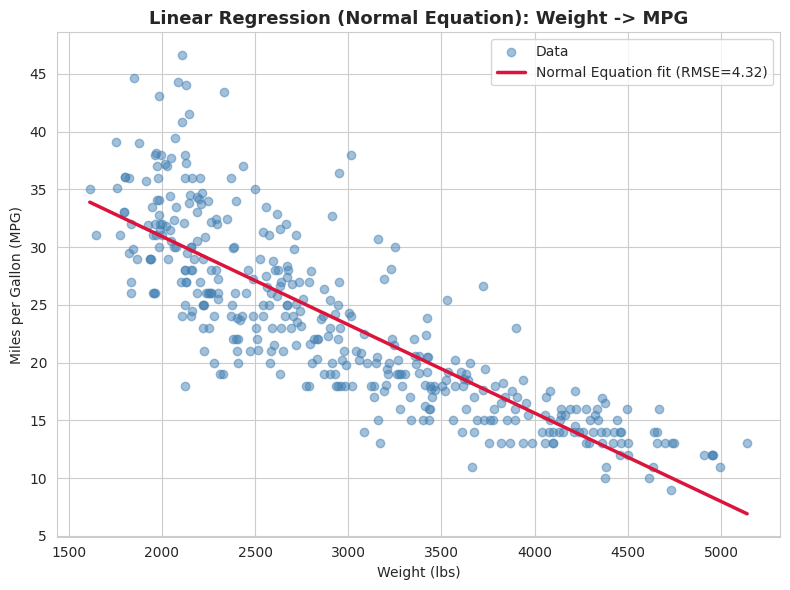

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['weight'], df['mpg'], alpha=0.5, color='steelblue', label='Data')

xline = np.linspace(df['weight'].min(), df['weight'].max(), 100)
yline = intercept + slope * xline
ax.plot(xline, yline, color='crimson', linewidth=2.5,
        label=f'Normal Equation fit (RMSE={rmse:.2f})')

ax.set_title('Linear Regression (Normal Equation): Weight -> MPG', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon (MPG)')
ax.legend()
plt.tight_layout()
plt.show()


In [18]:
# Compare against np.polyfit()
polyfit_slope, polyfit_intercept = np.polyfit(df['weight'], df['mpg'], 1)

print(f"Normal Equation -> slope: {slope:.6f}, intercept: {intercept:.6f}")
print(f"np.polyfit()    -> slope: {polyfit_slope:.6f}, intercept: {polyfit_intercept:.6f}")
print(f"Match (within floating-point tolerance): "
      f"{np.isclose(slope, polyfit_slope) and np.isclose(intercept, polyfit_intercept)}")


Normal Equation -> slope: -0.007647, intercept: 46.216525
np.polyfit()    -> slope: -0.007647, intercept: 46.216525
Match (within floating-point tolerance): True


Both approaches solve the same least-squares problem, so the slope and
intercept match essentially exactly (up to floating-point precision) —
`np.polyfit()` is itself solving a normal-equation-equivalent system under
the hood.


## Bonus 2 — 2D PCA from Scratch

In [19]:
# Use the same 5 numeric features
X_pca = df[feature_cols].to_numpy(dtype=float)

# 1. Mean-center
X_centered = X_pca - X_pca.mean(axis=0)

# 2. Covariance matrix
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

# 3. Eigen-decomposition (symmetric matrix -> eigh)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# eigh returns ascending order -> reverse for descending
order = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]

# 4. Top-2 eigenvectors
V2 = eigvecs_sorted[:, :2]

# 5. Project to 2D
Z = X_centered @ V2

# 6. Explained variance ratio
explained_var_ratio = eigvals_sorted[:2] / eigvals_sorted.sum()
print(f"PC1 explained variance ratio: {explained_var_ratio[0]:.4f}")
print(f"PC2 explained variance ratio: {explained_var_ratio[1]:.4f}")
print(f"Total (PC1+PC2): {explained_var_ratio.sum():.4f}")


PC1 explained variance ratio: 0.9976
PC2 explained variance ratio: 0.0021
Total (PC1+PC2): 0.9996


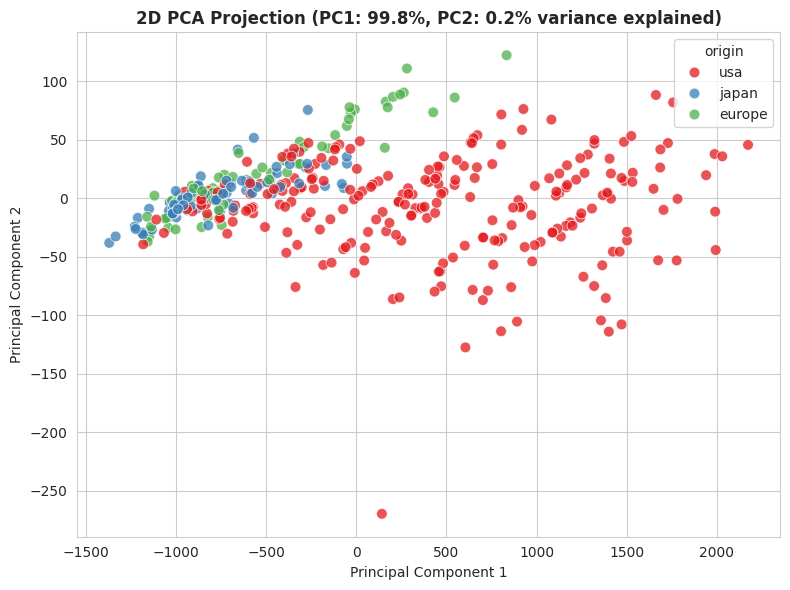

In [20]:
pca_df = pd.DataFrame(Z, columns=['PC1', 'PC2'])
pca_df['origin'] = df['origin'].values

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', palette='Set1',
                 alpha=0.75, s=60, ax=ax)
ax.set_title(
    f'2D PCA Projection (PC1: {explained_var_ratio[0]*100:.1f}%, '
    f'PC2: {explained_var_ratio[1]*100:.1f}% variance explained)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.tight_layout()
plt.show()


**Interpretation:** PC1 alone captures the large majority of the total
variance, consistent with the multicollinearity found earlier — since
`weight`, `displacement`, and `horsepower` move together, most of the
dataset's variability collapses onto a single "car size/power" axis.


## Bonus 3 — Reusable `DatasetProfiler` Class

In [21]:
class DatasetProfiler:
    """A lightweight, reusable EDA profiler built purely with NumPy/Pandas/
    Matplotlib/Seaborn (no scikit-learn)."""

    def __init__(self, df: pd.DataFrame, target_col: str):
        self.df = df.copy()
        self.target_col = target_col
        self.numeric_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()

    def summary_stats(self) -> pd.DataFrame:
        rows = []
        for col in self.numeric_cols:
            arr = self.df[col].to_numpy(dtype=float)
            q1, q3 = np.percentile(arr, [25, 75])
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_mask = (arr < lo) | (arr > hi)
            rows.append({
                'feature': col,
                'mean': arr.mean(),
                'median': np.median(arr),
                'std': arr.std(ddof=1),
                'IQR': iqr,
                'outlier_count': int(outlier_mask.sum())
            })
        return pd.DataFrame(rows).set_index('feature')

    def correlation_report(self) -> pd.Series:
        corr = self.df[self.numeric_cols].corr()[self.target_col]
        corr = corr.drop(self.target_col)
        return corr.sort_values(ascending=False)

    def _strongest_feature(self) -> str:
        return self.correlation_report().abs().idxmax()

    def plot_dashboard(self):
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))

        # (1) Target distribution
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0], color='steelblue')
        axes[0, 0].set_title(f'{self.target_col} Distribution')
        axes[0, 0].set_xlabel(self.target_col)

        # (2) Boxplot by category (first non-numeric column, if available)
        cat_cols = self.df.select_dtypes(exclude=[np.number]).columns.tolist()
        if cat_cols:
            cat_col = cat_cols[0]
            sns.boxplot(data=self.df, x=cat_col, y=self.target_col, ax=axes[0, 1], palette='Set2')
            axes[0, 1].set_title(f'{self.target_col} by {cat_col}')
        else:
            axes[0, 1].text(0.5, 0.5, 'No categorical column found', ha='center')
            axes[0, 1].set_title('Boxplot by Category (N/A)')

        # (3) Correlation heatmap
        corr_mat = self.df[self.numeric_cols].corr()
        sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    ax=axes[1, 0], cbar=False)
        axes[1, 0].set_title('Correlation Heatmap')

        # (4) Scatter of strongest feature vs target
        strongest = self._strongest_feature()
        sns.scatterplot(data=self.df, x=strongest, y=self.target_col, ax=axes[1, 1], alpha=0.6)
        axes[1, 1].set_title(f'{strongest} vs {self.target_col} (strongest correlate)')

        plt.tight_layout()
        plt.show()

    def generate_report(self) -> dict:
        stats = self.summary_stats()
        corr = self.correlation_report()
        return {
            'target_col': self.target_col,
            'n_rows': len(self.df),
            'n_numeric_features': len(self.numeric_cols),
            'summary_stats': stats.round(3).to_dict(orient='index'),
            'correlation_with_target': corr.round(4).to_dict(),
            'strongest_correlate': self._strongest_feature(),
        }


=== summary_stats() ===


,mean,median,std,IQR,outlier_count
feature,,,,,
mpg,23.446,22.750,7.805,12.000,0
cylinders,5.472,4.000,1.706,4.000,0
displacement,194.412,151.000,104.644,170.750,0
horsepower,104.469,93.500,38.491,51.000,10
weight,"2,977.584","2,803.500",849.403,"1,389.500",0
acceleration,15.541,15.500,2.759,3.250,11
model_year,75.980,76.000,3.684,6.000,0
decade,"1,972.168","1,970.000",4.126,0.000,85



=== correlation_report() ===


model_year      0.581
decade          0.576
acceleration    0.423
cylinders      -0.778
horsepower     -0.778
displacement   -0.805
weight         -0.832
Name: mpg, dtype: float64


=== plot_dashboard() ===


/tmp/ipykernel_579/3278144528.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x=cat_col, y=self.target_col, ax=axes[0, 1], palette='Set2')


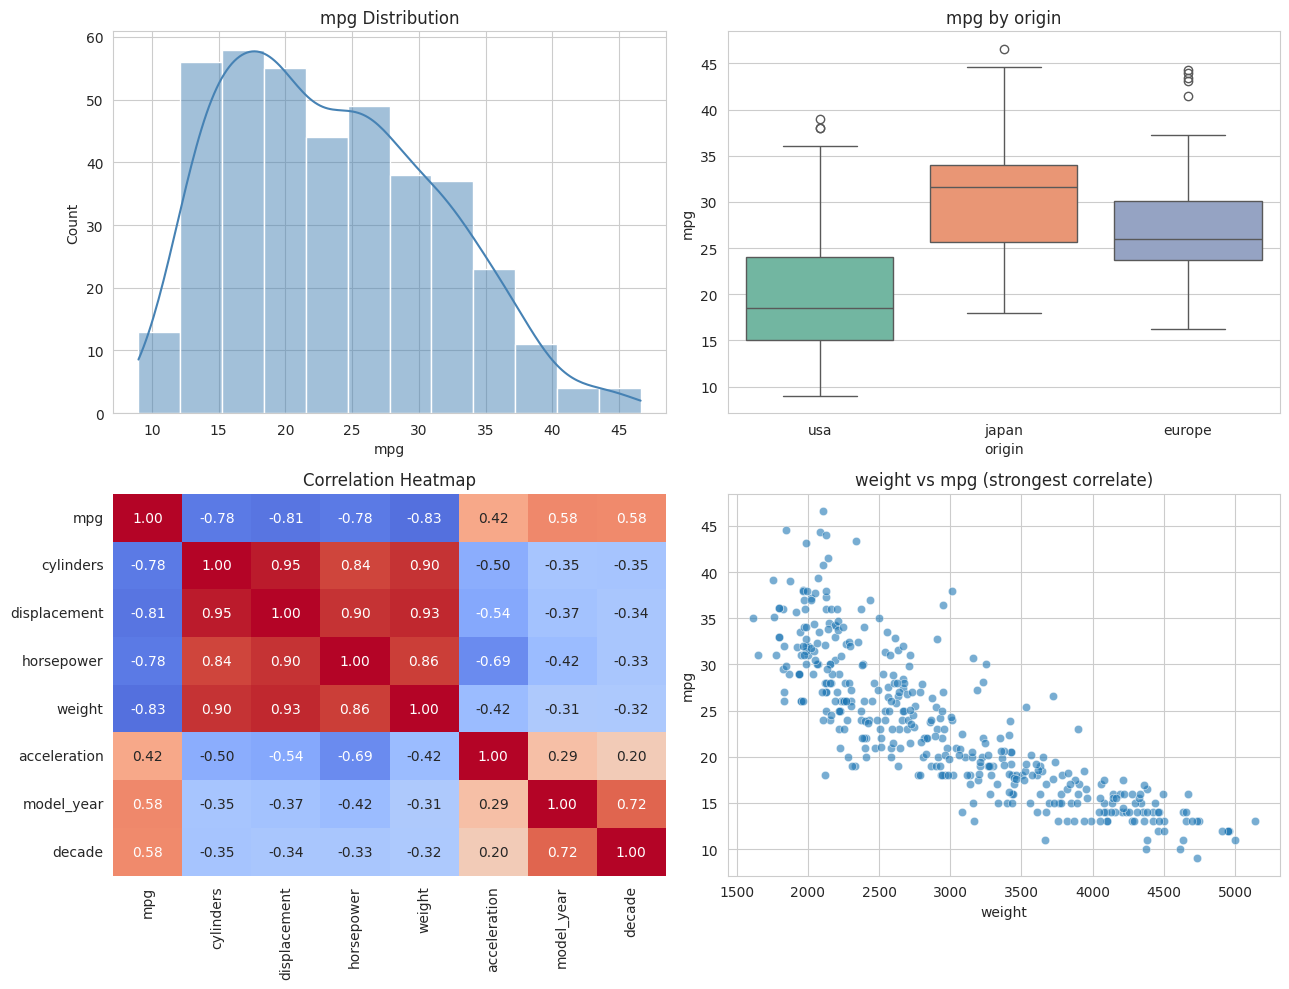


=== generate_report() ===
{
  "target_col": "mpg",
  "n_rows": 392,
  "n_numeric_features": 8,
  "summary_stats": {
    "mpg": {
      "mean": 23.446,
      "median": 22.75,
      "std": 7.805,
      "IQR": 12.0,
      "outlier_count": 0
    },
    "cylinders": {
      "mean": 5.472,
      "median": 4.0,
      "std": 1.706,
      "IQR": 4.0,
      "outlier_count": 0
    },
    "displacement": {
      "mean": 194.412,
      "median": 151.0,
      "std": 104.644,
      "IQR": 170.75,
      "outlier_count": 0
    },
    "horsepower": {
      "mean": 104.469,
      "median": 93.5,
      "std": 38.491,
      "IQR": 51.0,
      "outlier_count": 10
    },
    "weight": {
      "mean": 2977.584,
      "median": 2803.5,
      "std": 849.403,
      "IQR": 1389.5,
      "outlier_count": 0
    },
    "acceleration": {
      "mean": 15.541,
      "median": 15.5,
      "std": 2.759,
      "IQR": 3.25,
      "outlier_count": 11
    },
    "model_year": {
      "mean": 75.98,
      "median": 76.0,
  

In [22]:
profiler = DatasetProfiler(df, target_col='mpg')

print("=== summary_stats() ===")
display(profiler.summary_stats())

print("\n=== correlation_report() ===")
display(profiler.correlation_report())

print("\n=== plot_dashboard() ===")
profiler.plot_dashboard()

print("\n=== generate_report() ===")
report = profiler.generate_report()
import json
print(json.dumps(report, indent=2)[:1500], '...')


## Summary

- After cleaning, the dataset retains virtually all rows (only a handful of
  `horsepower` values were missing).
- `weight` is the single strongest predictor of `mpg`, with `displacement`
  and `horsepower` carrying largely redundant information (multicollinearity).
- Japanese and European vehicles are more fuel-efficient and more consistent
  than the historically heavier USA fleet.
- Average fuel efficiency rose across the observed decades, plausibly driven
  by the 1970s oil crises and the introduction of CAFE standards.
- A from-scratch Normal Equation regression matches `np.polyfit()` exactly,
  and PCA confirms that most of the feature variance collapses onto a single
  "car size" axis.
